# Лазар Владислав Игоревич
# Практическое задание по линейным моделям

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [3]:
import matplotlib.pyplot as plt

In [5]:
train_df = pd.read_csv("train.csv", parse_dates=["create_time", "model_create_time"], index_col='order_id')
webstat_df = pd.read_csv("t1_webstat.csv", parse_dates=["date_time"]).sort_values('date_time')
webstat_df['pageview_duration_sec'] = webstat_df['pageview_duration_sec'].clip(lower=0)
y = train_df["is_callcenter"]

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104595 entries, 1269921 to 1197777
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   create_time         104595 non-null  datetime64[ns]
 1   good_id             104595 non-null  int64         
 2   price               104595 non-null  int64         
 3   utm_medium          104595 non-null  int64         
 4   utm_source          94145 non-null   float64       
 5   sessionkey_id       104595 non-null  int64         
 6   category_id         104595 non-null  int64         
 7   parent_id           104595 non-null  int64         
 8   root_id             104595 non-null  int64         
 9   model_id            104595 non-null  int64         
 10  is_moderated        104595 non-null  int64         
 11  rating_value        33741 non-null   float64       
 12  rating_count        51613 non-null   float64       
 13  description_length  104595 

In [7]:
web_grouped = webstat_df.groupby('sessionkey_id')

In [8]:
session_lengths = web_grouped['pageview_duration_sec'].sum()

In [9]:
webstat_df.loc[:, 'product_in_sale'] = webstat_df['product_in_sale'].fillna(0)

## Информация о сессиях

In [10]:
session_info = pd.DataFrame({'duration': session_lengths})

In [11]:
session_info['num_pages'] = web_grouped.count()['pageview_number']

In [12]:
session_info['page_time_avg'] = web_grouped.mean()['pageview_duration_sec'].fillna(0)

In [13]:
session_info['page_time_std'] = web_grouped.std()['pageview_duration_sec'].fillna(0)

In [14]:
session_info['num_goods'] = web_grouped.count()['good_id'].fillna(0)

In [15]:
session_info['avg_price'] = web_grouped.mean()['price'].fillna(0)

In [16]:
session_info['std_price'] = web_grouped.std()['price'].fillna(0)

In [17]:
session_info

,duration,num_pages,page_time_avg,page_time_std,num_goods,avg_price,std_price
sessionkey_id,,,,,,,
109996122,90.0,7,15.000000,6.723095,0,0.0,0.00000
110019268,165.0,3,82.500000,55.861436,1,2986.0,0.00000
110020180,0.0,1,0.000000,0.000000,1,4490.0,0.00000
110040418,545.0,11,54.500000,80.525013,4,578.0,170.89568
110044482,0.0,1,0.000000,0.000000,1,4490.0,0.00000
...,...,...,...,...,...,...,...
134626779,22.0,1,22.000000,0.000000,0,0.0,0.00000
134627402,244.0,7,40.666667,42.828340,1,411.0,0.00000
134628420,93.0,5,23.250000,19.448650,0,0.0,0.00000


## Информация о товарах

In [18]:
goods_info = pd.DataFrame()

In [19]:
goods_info.index = webstat_df['good_id'].dropna().astype(int).unique()

In [20]:
goods_info['avg_price'] = webstat_df.groupby('good_id').mean()['price'].fillna(0)

In [21]:
goods_info = goods_info.merge(train_df.groupby('good_id').agg('mean')[['rating_value', 'rating_count']].fillna(0), left_index=True, right_index=True, how='left').fillna(0)

In [22]:
goods_info

,avg_price,rating_value,rating_count
22312252,2523.900000,0.0,0.0
55614318,4606.625000,0.0,0.0
10547740,691.879433,0.0,0.0
28114543,430.000000,0.0,1.0
62752433,5089.000000,0.0,0.0
...,...,...,...
68152262,936.000000,0.0,0.0
32815111,402.000000,0.0,0.0
75233530,2032.000000,0.0,0.0
75233841,1736.000000,0.0,0.0


## Страницы

In [23]:
def multiclass_label_data(column_name):
    webstat_df[column_name] = webstat_df[column_name].astype('category')

    page_info = (
        pd.get_dummies(webstat_df[column_name],
                    prefix=f'{column_name}',
                    prefix_sep='_',
                    dtype='uint8')
        .groupby(webstat_df['sessionkey_id'], sort=False).max()
    )

    return page_info.fillna(0).astype('category')

## Время

In [24]:
from sklearn.preprocessing import KBinsDiscretizer

In [25]:
from sklearn.compose import ColumnTransformer

In [26]:
n_time_bins = 6
disc = KBinsDiscretizer(n_bins=n_time_bins)

In [27]:
ct = ColumnTransformer([
    ('time_disc', disc, ['sec_before_order', 'sec_after_order']),
    ('time_enc', OneHotEncoder(), ['hour'])
    ], remainder='passthrough')

In [28]:
def get_time_features(df, val=False):
    order_time = df[['create_time', 'sessionkey_id']]
    session_start_time = web_grouped.min()['date_time'].to_frame()
    session_start_time.columns = ['start_time']
    session_end_time = web_grouped.max()['date_time'].to_frame()
    session_end_time.columns = ['end_time']
    time_features = order_time.merge(session_start_time, left_on='sessionkey_id', right_index=True, how='left').merge(
        session_end_time, left_on='sessionkey_id', right_index=True, how='left').drop(columns='sessionkey_id')
    time_features['sec_before_order'] = (time_features['create_time'] - time_features['start_time']).dt.seconds
    time_features['sec_after_order'] = (time_features['end_time'] - time_features['create_time']).dt.seconds
    time_features['hour'] = time_features['create_time'].dt.hour
    time_features['is_weekend'] = time_features['create_time'].dt.dayofweek.isin([5, 6])

    time_features.drop(columns=['start_time', 'end_time', 'create_time'], inplace=True)

    if val:
        tf = ct.transform(time_features.fillna(0))
    else:
        tf = ct.fit_transform(time_features.fillna(0))

    enc_tf = pd.DataFrame.sparse.from_spmatrix(tf)
    enc_tf.index = time_features.index
    enc_tf.columns = [f'sec_before_order_{i}' for i in range(1, 1 + n_time_bins)] + [f'sec_after_order_{i}' for i in range(1, 1 + n_time_bins)] + [f'hour_{i}' for i in range(1, 1 + 12)] + [f'is_weekend']

    return enc_tf.sparse.to_dense().astype('category')

In [29]:
tf = get_time_features(train_df)
tf

,sec_before_order_1,sec_before_order_2,sec_before_order_3,sec_before_order_4,sec_before_order_5,sec_before_order_6,sec_after_order_1,sec_after_order_2,sec_after_order_3,sec_after_order_4,...,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,is_weekend
order_id,,,,,,,,,,,,,,,,,,,,,
1269921,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1270034,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1268272,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1270544,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1270970,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250981,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1173775,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1180920,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Итоговый код

In [30]:
def enrich_dataset(df, val=False):
    page_type_info = multiclass_label_data('page_type')
    X = df.merge(page_type_info, left_on='sessionkey_id', right_index=True, how='left')
    time_features = get_time_features(X, val)
    X = X.merge(time_features, left_index=True, right_index=True, how='left')

    y = X['is_callcenter'] if 'is_callcenter' in X.columns else None
    X = X[['sessionkey_id', 'good_id'] + list(page_type_info.columns) + list(time_features.columns)]
    X = X.merge(session_info, left_on='sessionkey_id', right_index=True, how='left').merge(goods_info, left_on='good_id', right_index=True, how='left')

    X.fillna(0, inplace=True)
    X.drop(columns=['sessionkey_id', 'good_id'], inplace=True)
    return X, y

In [31]:
# Всё то же что и выше, но оформлено в виде класса для дальнейшего удобства
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer, StandardScaler
from sklearn.compose import ColumnTransformer

class DataEnricher:
    def __init__(self, webstat_df):
        self.webstat_df = webstat_df
        self.web_grouped = webstat_df.groupby('sessionkey_id')
        self.web_grouped.mean()

        self.webstat_df.loc[:, 'product_in_sale'] = webstat_df['product_in_sale'].fillna(0)

        self.n_time_bins = 6
        self.ct = ColumnTransformer([
            ('time_disc', KBinsDiscretizer(n_bins=self.n_time_bins), ['sec_before_order', 'sec_after_order']),
            ('time_enc', OneHotEncoder(), ['hour'])
            ], remainder='passthrough')

    def _get_session_info(self):
        # Информация о сессиях
        session_lengths = self.web_grouped['pageview_duration_sec'].sum()
        session_info = pd.DataFrame({'duration': session_lengths})

        session_info['num_pages'] = self.web_grouped.count()['pageview_number']
        session_info['page_time_avg'] = self.web_grouped.mean()['pageview_duration_sec'].fillna(0)
        session_info['page_time_std'] = self.web_grouped.std()['pageview_duration_sec'].fillna(0)
        session_info['num_goods'] = self.web_grouped.count()['good_id'].fillna(0)
        session_info['avg_price'] = self.web_grouped.mean()['price'].fillna(0)
        session_info['std_price'] = self.web_grouped.std()['price'].fillna(0)

        return session_info


    def _get_goods_info(self, df):
        # Информация о товарах
        goods_info = pd.DataFrame()
        goods_info.index = self.webstat_df['good_id'].dropna().astype(int).unique()
        goods_info['avg_price'] = self.webstat_df.groupby('good_id').mean()['price'].fillna(0)
        goods_info = goods_info.merge(df.groupby('good_id').agg('mean')[['rating_value', 'rating_count']].fillna(0), left_index=True, right_index=True, how='left').fillna(0)

        return goods_info

    def _multiclass_label_data(self, column_name):
        page_info = (
            pd.get_dummies(self.webstat_df[column_name].astype('category'),
                        prefix=f'{column_name}',
                        prefix_sep='_',
                        dtype='uint8')
            .groupby(self.webstat_df['sessionkey_id'], sort=False).max()
        )

        return page_info.fillna(0).astype('category')

    def _get_time_features(self, df, val=False):
        # Время
        order_time = df[['create_time', 'sessionkey_id']]
        session_start_time = self.web_grouped.min()['date_time'].to_frame()
        session_start_time.columns = ['start_time']
        session_end_time = self.web_grouped.max()['date_time'].to_frame()
        session_end_time.columns = ['end_time']
        time_features = order_time.merge(session_start_time, left_on='sessionkey_id', right_index=True, how='left').merge(
            session_end_time, left_on='sessionkey_id', right_index=True, how='left').drop(columns='sessionkey_id')
        time_features['sec_before_order'] = (time_features['create_time'] - time_features['start_time']).dt.seconds
        time_features['sec_after_order'] = (time_features['end_time'] - time_features['create_time']).dt.seconds
        time_features['hour'] = time_features['create_time'].dt.hour
        time_features['is_weekend'] = time_features['create_time'].dt.dayofweek.isin([5, 6])

        time_features.drop(columns=['start_time', 'end_time', 'create_time'], inplace=True)

        if val:
            tf = self.ct.transform(time_features.fillna(0))
        else:
            tf = self.ct.fit_transform(time_features.fillna(0))

        enc_tf = pd.DataFrame.sparse.from_spmatrix(tf)
        enc_tf.index = time_features.index
        enc_tf.columns = [f'sec_before_order_{i}' for i in range(1, 1 + self.n_time_bins)] + [f'sec_after_order_{i}' for i in range(1, 1 + self.n_time_bins)] + [f'hour_{i}' for i in range(1, 1 + 12)] + [f'is_weekend']

        return enc_tf.sparse.to_dense().astype('category')

    def fit(self, X, y):
        tf = self._get_time_features(X)
        page_type_info = self._multiclass_label_data('page_type')
        session_info = self._get_session_info()
        goods_info = self._get_goods_info(X)
        time_features = self._get_time_features(X)

        X = X.merge(page_type_info, left_on='sessionkey_id', right_index=True, how='left')
        X = X.merge(time_features, left_index=True, right_index=True, how='left')

        X = X[['sessionkey_id', 'good_id'] + list(page_type_info.columns) + list(time_features.columns)]

        X = X.merge(session_info, left_on='sessionkey_id', right_index=True, how='left').merge(goods_info, left_on='good_id', right_index=True, how='left')

        X.fillna(0, inplace=True)
        X.drop(columns=['sessionkey_id', 'good_id'], inplace=True)
        return X

    def transform(self, X):
        tf = self._get_time_features(X)
        page_type_info = self._multiclass_label_data('page_type')
        session_info = self._get_session_info()
        goods_info = self._get_goods_info(X)
        time_features = self._get_time_features(X, True)

        X = X.merge(page_type_info, left_on='sessionkey_id', right_index=True, how='left')
        X = X.merge(time_features, left_index=True, right_index=True, how='left')

        X = X[['sessionkey_id', 'good_id'] + list(page_type_info.columns) + list(time_features.columns)]

        X = X.merge(session_info, left_on='sessionkey_id', right_index=True, how='left').merge(goods_info, left_on='good_id', right_index=True, how='left')

        X.fillna(0, inplace=True)
        X.drop(columns=['sessionkey_id', 'good_id'], inplace=True)
        return X

    def fit_transform(self, X, y):
        self.fit(X, y)
        X_new = self.transform(X)
        return X_new

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegressionCV
from sklearn.decomposition import TruncatedSVD


def build_model():
    pipe = Pipeline([
        ('enrich', DataEnricher(webstat_df)),
        ('scale_numeric', ColumnTransformer(
            [('scaler', StandardScaler(), ['duration', 'num_pages', 'page_time_avg', 'page_time_std', 'num_goods', 'avg_price_x', 'std_price', 'avg_price_y', 'rating_value',  'rating_count']),],
            remainder='passthrough'
        )),
        ('interact', PolynomialFeatures(include_bias=True, degree=2)),
        ('compress', TruncatedSVD(n_components=1200)),
        ('clf', LogisticRegressionCV(class_weight='balanced',
                        solver='lbfgs', max_iter=10000, n_jobs=-1, scoring='roc_auc'))
    ])

    return pipe

In [33]:
y = train_df['is_callcenter']
X = train_df.drop(columns='is_callcenter')

In [34]:
model = build_model()

In [35]:
model

,steps,"[('enrich', ...), ('scale_numeric', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

def solve(X, y, model, full_train=False):
    X_train, X_val, y_train, y_val = train_test_split(X, y)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    RocCurveDisplay.from_predictions(y_val, y_pred)
    print(roc_auc_score(y_val, y_pred))

    if full_train:
        model.fit(X, y)

    return model

def submit(X_test, model):
    test_preds = model.predict_proba(X_test)[:, 1]

    pd.DataFrame({
        "order_id": test_df.index,
        "is_callcenter": test_preds
    }).to_csv("submission.csv", index=False)

    return model.predict(X)

0.9401411422721643


KeyboardInterrupt: 

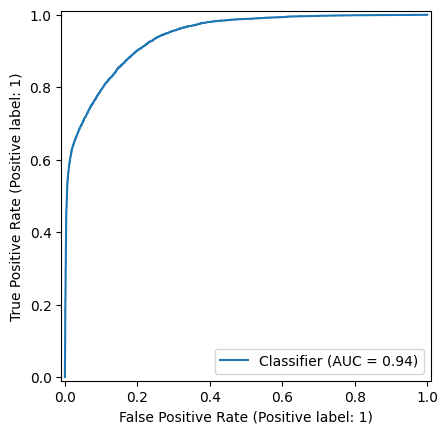

In [37]:
model = solve(X, y, model, True)

In [ ]:
model['clf'].coef_.shape

(1, 1200)

In [ ]:
test_df = pd.read_csv('test.csv', parse_dates=["create_time", "model_create_time"], index_col='order_id')

In [ ]:
proba = model.predict_proba(X)[:, 1]

In [ ]:
roc_auc_score(y, proba)

0.9452760079101542

In [ ]:
y_test_pred = submit(test_df, model)